In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:

import numpy as np
import matplotlib.pyplot as plt


from src.utils import *
from src.fista_logreg import *
from src.unlabeled_logreg import *
from src.missing_schemes import *

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import seaborn as sns

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score

### Dataset loading and preprocessing

In this step, we load and preprocess 4 datasets used in the experiments.

For each dataset:
- The data is loaded using a `load_dataset` function.
- Highly correlated features are removed using `prepare_dataset` (with a correlation threshold of 0.9) to reduce redundancy and improve model stability.
- The target variable `y` is aligned with the filtered feature matrix `X`.
- A dataset summary is printed to provide basic information about the data.
- If any features are removed due to high correlation, they are reported.

Finally, all processed datasets are stored in a dictionary for further experimentation.

In [ ]:
processed_datasets = {}

datasets = ["biodeg", "magic", "pendigits", "higgs"]

for name in datasets:

    X, y = load_dataset(name)
    X, removed = prepare_dataset(X, threshold=0.9)
    y = y.loc[X.index]
    dataset_summary(X, y, name)
    if removed:
        print(f"Removed features due to high correlation: {removed}\n")

    processed_datasets[name] = {
        "X": X,
        "y": y,
    }

----------------------------------------
Dataset: biodeg
----------------------------------------
Number of samples: 1055
Number of features: 38

Target distribution:
Class
1    699
0    356
Name: count, dtype: int64


Removed features due to high correlation: ['V15', 'V27', 'V39']

----------------------------------------
Dataset: magic
----------------------------------------
Number of samples: 19020
Number of features: 9

Target distribution:
class
1    12332
0     6688
Name: count, dtype: int64


Removed features due to high correlation: ['fConc1']

----------------------------------------
Dataset: pendigits
----------------------------------------
Number of samples: 10992
Number of features: 16

Target distribution:
binaryClass
0    9848
1    1144
Name: count, dtype: int64


----------------------------------------
Dataset: higgs
----------------------------------------
Number of samples: 98049
Number of features: 28

Target distribution:
class
1    51826
0    46223
Name: count, d

### Evaluation metrics

- **Accuracy**: overall fraction of correctly classified samples
- **Balanced accuracy**: accounts for class imbalance by averaging recall across classes
- **F1-score**: harmonic mean of precision and recall
- **ROC AUC**: measures the model's ability to distinguish between classes based on predicted probabilities


In [38]:
def evaluate(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba)
    }


In [ ]:
missing_generators = {
    "MCAR": generate_mcar,
    "MAR1": generate_mar1,
    "MAR2": generate_mar2,
    "MNAR": generate_mnar
}

N_SPLITS = 5
MISSING_RATE = np.arange(0, 0.9, 0.05)

ulr_methods = ["pseudo_labeling", "kmeans_majority", "naive"]
lambda_grid = np.logspace(-6, 1, 20)

### Experimental pipeline

The `run_experiment` function runs the full experimental procedure across multiple datasets and data splits.

The workflow is as follows:

1. **Data splitting**
   - Each dataset is split into training, validation, and test sets.
   - The split is repeated multiple times (`N_SPLITS`) for robustness.

2. **Preprocessing**
   - Features are scaled using Min-Max normalization.

3. **Oracle model (baseline)**
   - A fully supervised model (`FISTALogisticLasso`) is trained using only labeled data.
   - Hyperparameter λ is selected using validation data.

4. **Missing label simulation**
   - Different missing label mechanisms are applied using predefined generators.
   - Various missing rates (`MISSING_RATE`) are tested.

5. **Semi-supervised learning**
   - The `UnlabeledLogReg` model is trained using different strategies:
     - pseudo-labeling
     - k-means majority voting
     - naive (labeled only)
   - The number of clusters is dynamically adjusted based on dataset size.

6. **Evaluation**
   - Each model is evaluated on the test set using multiple metrics.
   - Results are saved incrementally to a CSV file.

This pipeline allows systematic comparison of methods under varying levels of missing labels.

In [ ]:
def run_experiment(processed_datasets, output_csv="results_experiment.csv"):

    results = []

    pd.DataFrame().to_csv(output_csv, index=False)

    for dataset_name, data in processed_datasets.items():

        print(f"\n=== DATASET: {dataset_name} ===")

        X = data["X"].values
        y = data["y"].values

        for split in range(N_SPLITS):

            print(f"Split {split+1}/{N_SPLITS}")

            X_temp, X_test, y_temp, y_test = train_test_split(
                X, y, test_size=0.2, random_state=split
            )

            val_size = 0.1 / 0.8 
            X_train, X_val, y_train, y_val = train_test_split(
                X_temp, y_temp, test_size=val_size, random_state=split)

            scaler = MinMaxScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)
            X_test = scaler.transform(X_test)

            oracle_val = FISTALogisticLasso(lambda_values=lambda_grid)
            oracle_val.fit(X_train, y_train, auto_validate = True, X_valid=X_val, y_valid= y_val)
            y_pred = oracle_val.predict(X_test)
            y_proba = oracle_val.predict_proba(X_test)

            result_row = {
                "dataset": dataset_name,
                "split": split,
                "missing_type": None,
                "missing_rate": None,
                "method": "oracle",
                "lambda": oracle_val.best_lambda_,
                **evaluate(y_test, y_pred, y_proba)
            }
            results.append(result_row)
            pd.DataFrame([result_row]).to_csv(output_csv, mode="a", index=False, header=False)

            for missing_name, generator in missing_generators.items():

                for c in MISSING_RATE:

                    X_miss, y_obs = generator(pd.DataFrame(X_train), pd.Series(y_train), c)
                    X_miss = np.array(X_miss)
                    y_obs = np.array(y_obs)

                    n_labeled = np.sum(y_obs != -1)
                    n_unlabeled = np.sum(y_obs == -1)

                    if n_labeled < 5:
                        print(f"Skipping {missing_name} rate={c:.2f}, too few labeled ({n_labeled})")
                        continue

                    for method in ulr_methods:

                        n_clusters = min(20, max(2, X_train.shape[0] // 20))

                        model_val = UnlabeledLogReg(
                            method=method,
                            fista_params={"lambda_values": lambda_grid},
                            n_clusters=n_clusters
                        )

                        try:
                            model_val.fit(X_miss, y_obs, X_val, y_val)
                        except ValueError as e:
                            print(f"Skipping {method} at missing_rate={c:.2f}: {e}")
                            continue

                        y_pred = model_val.predict(X_test)
                        y_proba = model_val.predict_proba(X_test)

                        result_row = {
                            "dataset": dataset_name,
                            "split": split,
                            "missing_type": missing_name,
                            "missing_rate": c,
                            "method": method,
                            "lambda": model_val.model_.lam if hasattr(model_val.model_, "lam") else None,
                            **evaluate(y_test, y_pred, y_proba)
                        }

                        results.append(result_row)
                        pd.DataFrame([result_row]).to_csv(output_csv, mode="a", index=False, header=False)

    return pd.DataFrame(results)

In [ ]:
results_all = run_experiment(processed_datasets)


=== DATASET: biodeg ===
Split 1/5
Split 2/5
Split 3/5
Split 4/5
Split 5/5

=== DATASET: magic ===
Split 1/5
Split 2/5
Split 3/5
Split 4/5
Split 5/5

=== DATASET: pendigits ===
Split 1/5
Split 2/5
Split 3/5
Split 4/5
Split 5/5

=== DATASET: higgs ===
Split 1/5
Split 2/5


### Analysis

In [8]:
df = pd.read_csv("results_experiment.csv")
metrics = ["accuracy", "balanced_accuracy", "f1", "roc_auc"]

In [9]:
c_fixed = 0.3
df.loc[df["method"] == "oracle", "missing_rate"] = c_fixed
df.loc[df["method"] == "oracle", "missing_type"] = "FULL"

group_cols = ["dataset", "method", "missing_type", "missing_rate"]

summary = df.groupby(group_cols)[metrics].agg(["mean", "std"]).reset_index()

summary.columns = [
    "_".join(col).strip("_") for col in summary.columns.values
]

### Experiment 1: Performance comparison at a fixed missing rate

In this experiment, we analyze model performance at a fixed missing rate (c = 0.3).

Steps:
- Results are grouped by dataset, method, missing data type, and missing rate.
- Mean and standard deviation of evaluation metrics are computed.
- A summary table is created for easier comparison.

Additionally:
- Results are visualized using bar plots.
- Each subplot corresponds to a different metric.
- Error bars represent standard deviation across splits.
- Methods are compared across different missing data mechanisms.

This analysis highlights how different approaches perform under a moderate level of missing labels.

In [10]:
table_exp1 = summary[summary["missing_rate"] == c_fixed]

for dataset in table_exp1["dataset"].unique():
    print(f"\n=== DATASET: {dataset} ===")
    
    display(
        table_exp1[table_exp1["dataset"] == dataset]
        .sort_values(["missing_type", "method"])
    )


=== DATASET: biodeg ===


,dataset,method,missing_type,missing_rate,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
144,biodeg,oracle,FULL,0.3,0.837915,0.030969,0.821166,0.030015,0.876476,0.029029,0.909044,0.021641
6,biodeg,kmeans_majority,MAR1,0.3,0.828436,0.022828,0.807223,0.021984,0.870463,0.021977,0.898232,0.019759
78,biodeg,naive,MAR1,0.3,0.839810,0.022077,0.825839,0.021449,0.877646,0.022088,0.904944,0.025310
151,biodeg,pseudo_labeling,MAR1,0.3,0.828436,0.034568,0.803331,0.038838,0.871923,0.029447,0.907155,0.021127
24,biodeg,kmeans_majority,MAR2,0.3,0.831280,0.028945,0.814810,0.027145,0.870838,0.027612,0.899455,0.017513
96,biodeg,naive,MAR2,0.3,0.830332,0.028711,0.814787,0.028860,0.870013,0.027679,0.904393,0.028755
169,biodeg,pseudo_labeling,MAR2,0.3,0.838863,0.030531,0.818653,0.036232,0.878825,0.025347,0.909378,0.021954
42,biodeg,kmeans_majority,MCAR,0.3,0.826540,0.038298,0.807921,0.039993,0.867898,0.034852,0.897550,0.018401
114,biodeg,naive,MCAR,0.3,0.833175,0.017219,0.814994,0.017204,0.873472,0.018477,0.903262,0.024694
187,biodeg,pseudo_labeling,MCAR,0.3,0.837915,0.025390,0.812419,0.032469,0.879511,0.020696,0.908276,0.016378



=== DATASET: higgs ===


,dataset,method,missing_type,missing_rate,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
359,higgs,oracle,FULL,0.3,0.640745,0.000649,0.634939,0.000360,0.685881,0.001677,0.682080,0.001052
221,higgs,kmeans_majority,MAR1,0.3,0.615298,0.005769,0.601666,0.007911,0.701812,0.003828,0.664738,0.004634
293,higgs,naive,MAR1,0.3,0.640413,0.002488,0.634877,0.001903,0.684143,0.004916,0.681072,0.001833
366,higgs,pseudo_labeling,MAR1,0.3,0.638373,0.000974,0.632106,0.002001,0.686110,0.003998,0.680225,0.000426
239,higgs,kmeans_majority,MAR2,0.3,0.609052,0.003065,0.598393,0.007396,0.682736,0.019410,0.652572,0.010907
311,higgs,naive,MAR2,0.3,0.643116,0.002200,0.637294,0.002506,0.688077,0.000772,0.685053,0.001702
384,higgs,pseudo_labeling,MAR2,0.3,0.639699,0.004940,0.632198,0.006756,0.693434,0.004158,0.681865,0.004270
257,higgs,kmeans_majority,MCAR,0.3,0.613845,0.004219,0.600502,0.007516,0.699359,0.012274,0.665558,0.011539
329,higgs,naive,MCAR,0.3,0.638730,0.003426,0.632668,0.003604,0.685436,0.002538,0.680330,0.002531
402,higgs,pseudo_labeling,MCAR,0.3,0.636308,0.001731,0.629547,0.001611,0.686914,0.002617,0.679961,0.000844



=== DATASET: magic ===


,dataset,method,missing_type,missing_rate,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
572,magic,oracle,FULL,0.3,0.783912,0.003619,0.737249,0.003626,0.842884,0.003956,0.833857,0.005237
434,magic,kmeans_majority,MAR1,0.3,0.785804,0.002760,0.732212,0.004193,0.846740,0.003068,0.823690,0.006780
506,magic,naive,MAR1,0.3,0.785279,0.003379,0.739775,0.002333,0.843497,0.004197,0.831782,0.006667
579,magic,pseudo_labeling,MAR1,0.3,0.784175,0.002927,0.737907,0.003816,0.842920,0.003723,0.833277,0.006183
452,magic,kmeans_majority,MAR2,0.3,0.784332,0.006223,0.732140,0.008917,0.845072,0.005380,0.824041,0.006961
524,magic,naive,MAR2,0.3,0.784175,0.003049,0.738549,0.005728,0.842609,0.004812,0.831678,0.008259
597,magic,pseudo_labeling,MAR2,0.3,0.784911,0.002419,0.738869,0.007406,0.843325,0.004008,0.832206,0.006496
470,magic,kmeans_majority,MCAR,0.3,0.784280,0.003152,0.727105,0.006721,0.846750,0.003517,0.823160,0.007103
542,magic,naive,MCAR,0.3,0.785226,0.002254,0.738866,0.003236,0.843806,0.002927,0.833211,0.006020
615,magic,pseudo_labeling,MCAR,0.3,0.784069,0.003451,0.737192,0.003796,0.843059,0.004023,0.833440,0.005604



=== DATASET: pendigits ===


,dataset,method,missing_type,missing_rate,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
786,pendigits,oracle,FULL,0.3,0.991087,0.000407,0.977239,0.003931,0.957685,0.002572,0.998476,0.000655
648,pendigits,kmeans_majority,MAR1,0.3,0.988085,0.000875,0.974732,0.011363,0.943970,0.006595,0.997611,0.001352
720,pendigits,naive,MAR1,0.3,0.990723,0.000996,0.975077,0.003777,0.955718,0.006483,0.998221,0.000709
793,pendigits,pseudo_labeling,MAR1,0.3,0.991633,0.000610,0.979951,0.005663,0.960445,0.002238,0.998390,0.000744
666,pendigits,kmeans_majority,MAR2,0.3,0.986085,0.003289,0.966334,0.020442,0.933870,0.017413,0.997168,0.001679
738,pendigits,naive,MAR2,0.3,0.990632,0.001229,0.976224,0.006105,0.955470,0.006673,0.998075,0.001058
811,pendigits,pseudo_labeling,MAR2,0.3,0.989541,0.002109,0.977604,0.006234,0.950997,0.008876,0.997779,0.001109
684,pendigits,kmeans_majority,MCAR,0.3,0.985903,0.001982,0.978474,0.007340,0.935357,0.008516,0.997880,0.000475
756,pendigits,naive,MCAR,0.3,0.991905,0.001086,0.978926,0.005872,0.961698,0.003710,0.998547,0.000640
829,pendigits,pseudo_labeling,MCAR,0.3,0.992087,0.001047,0.980849,0.003883,0.962584,0.004454,0.998431,0.000696


In [11]:
sns.set(style="whitegrid")

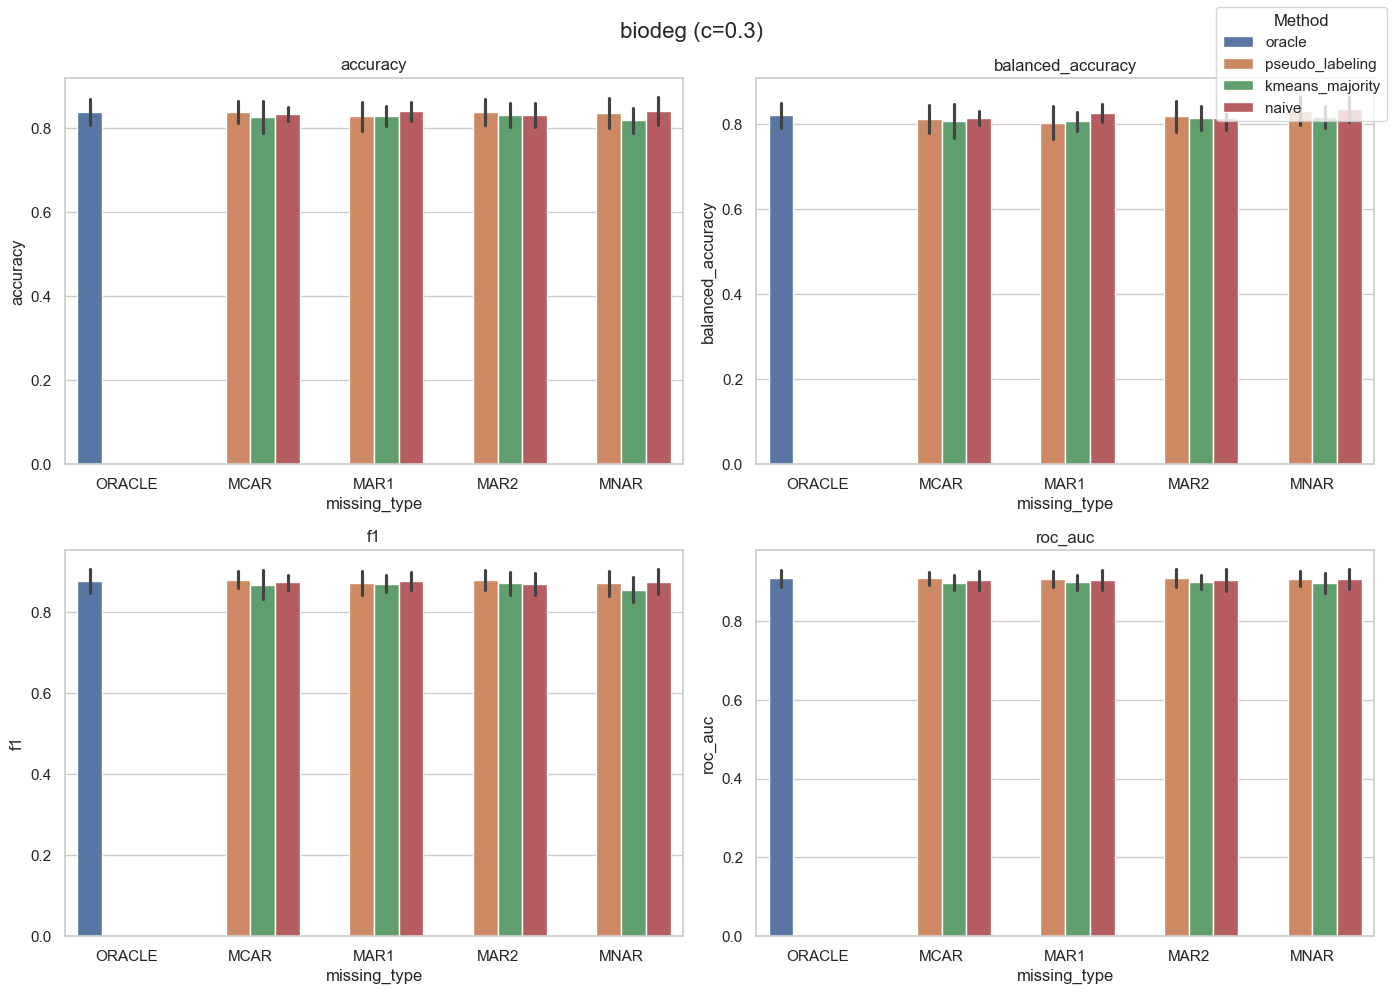

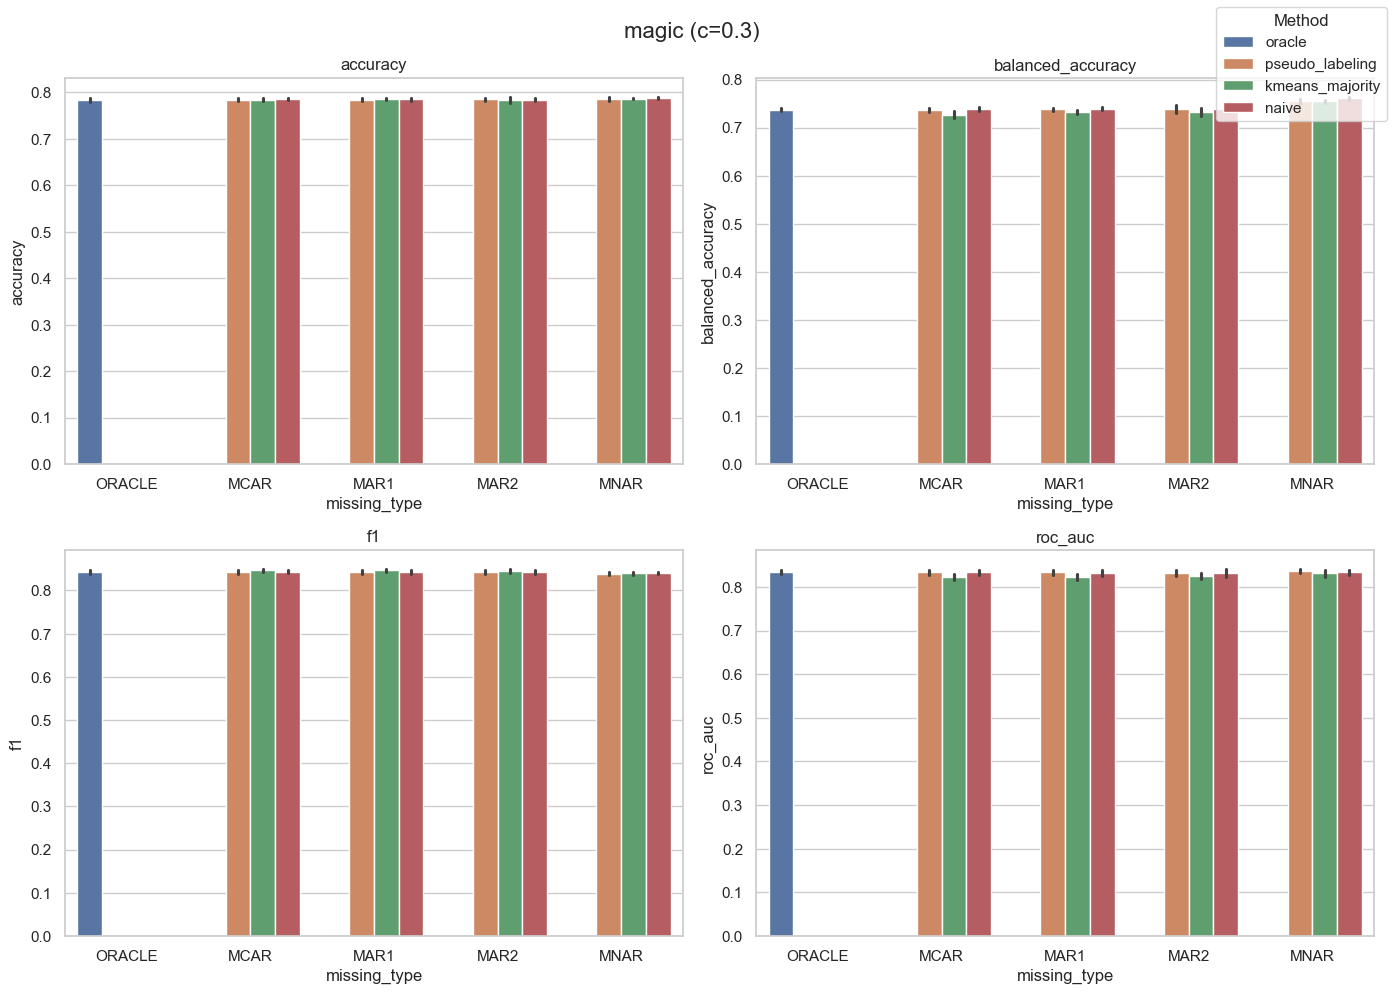

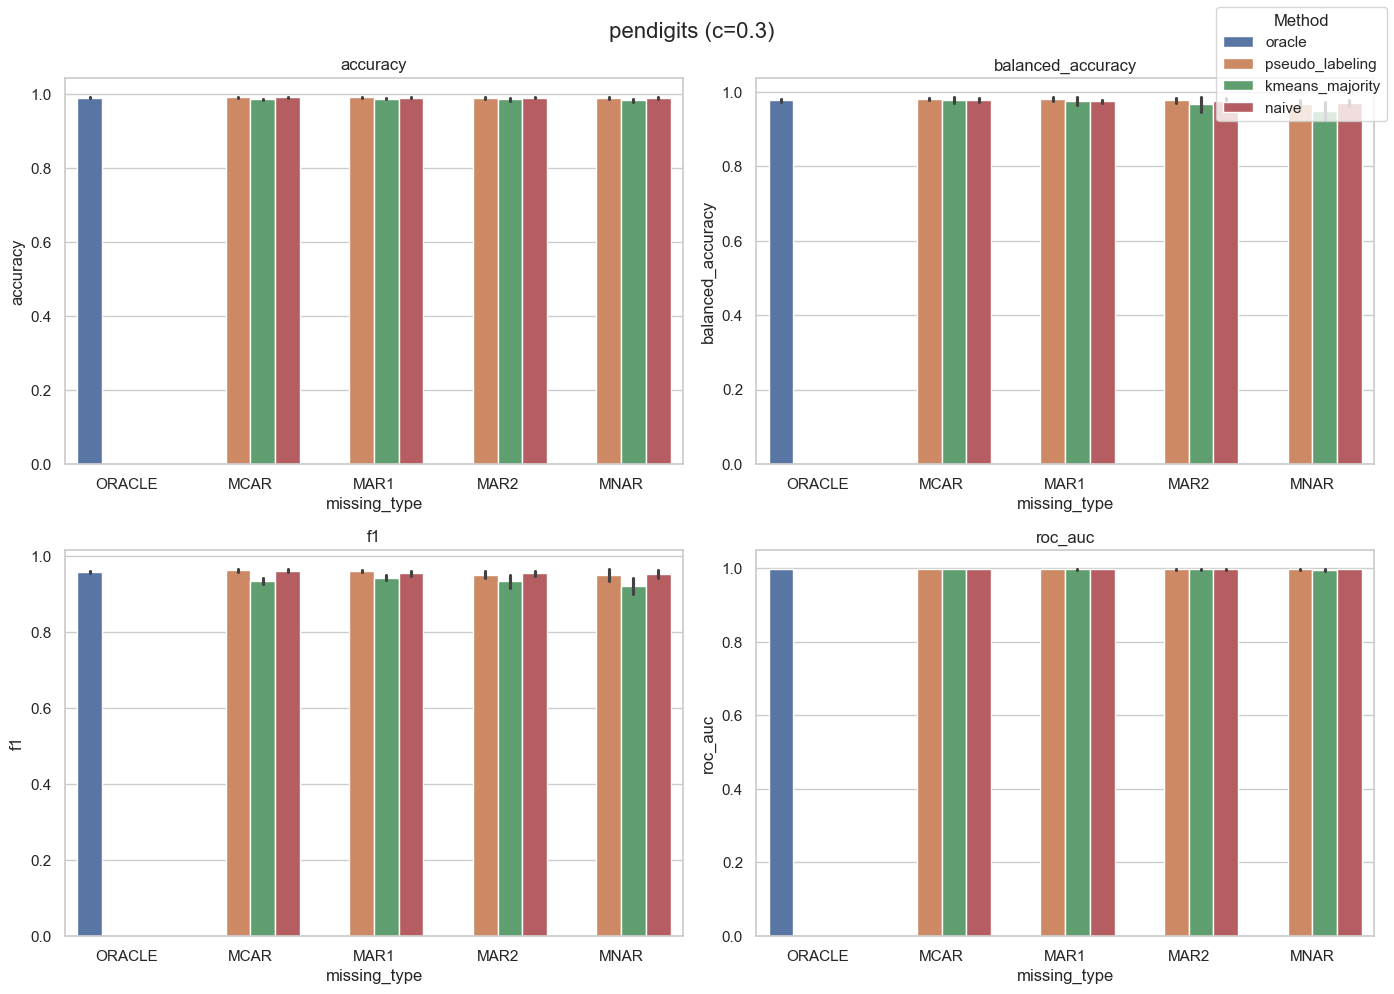

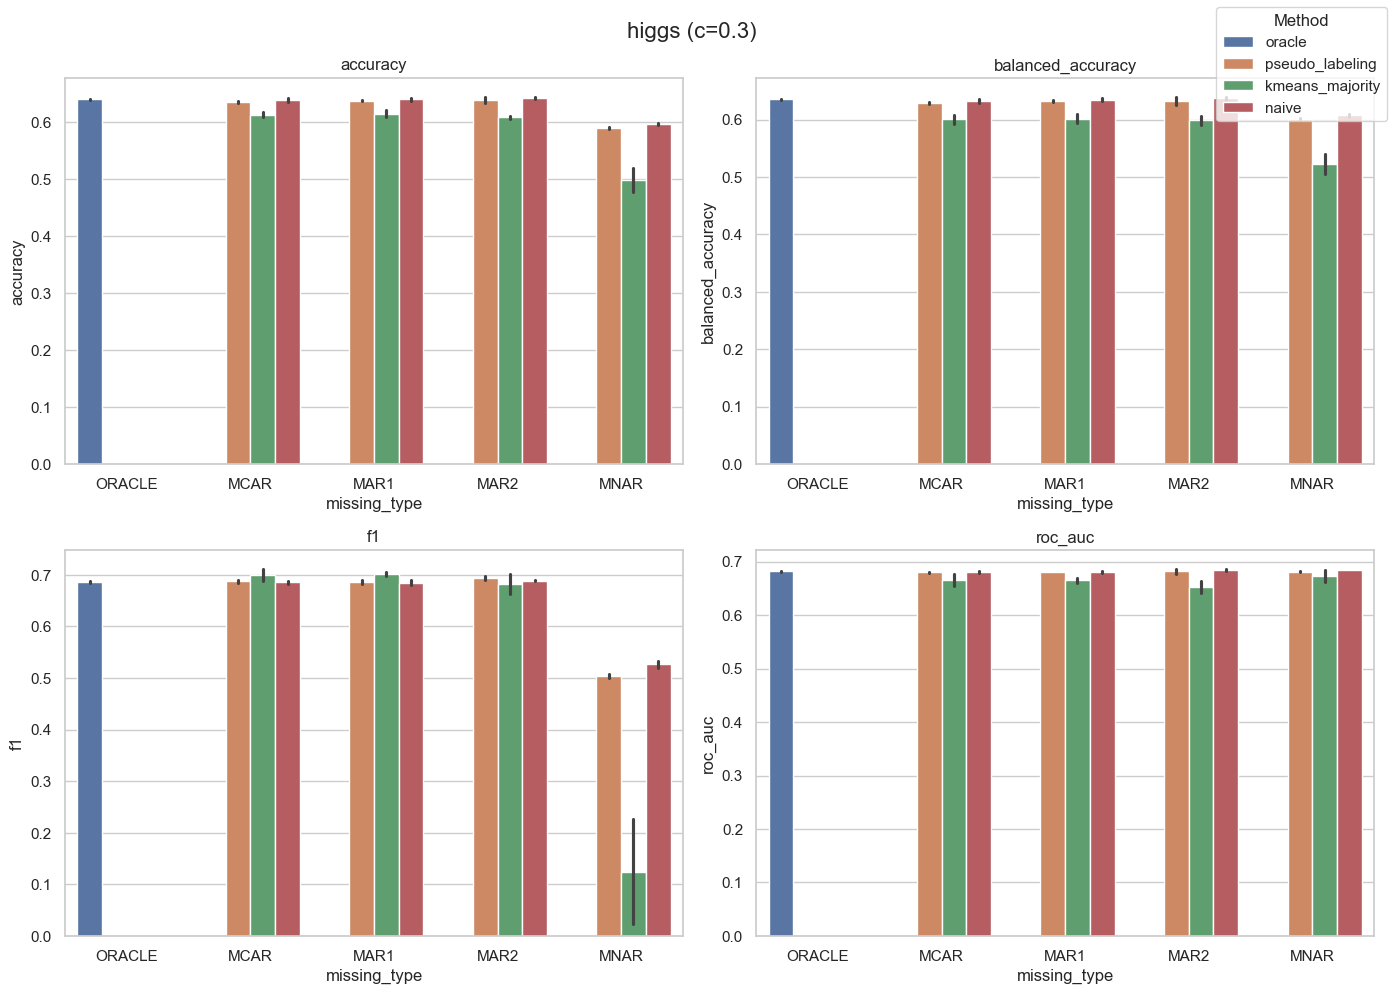

In [ ]:
c_fixed = 0.3

df_plot = df.copy()

df_plot.loc[df_plot["method"] == "oracle", "missing_rate"] = c_fixed
df_plot.loc[df_plot["method"] == "oracle", "missing_type"] = "ORACLE"

df_exp1 = df_plot[df_plot["missing_rate"] == c_fixed]

order = ["ORACLE", "MCAR", "MAR1", "MAR2", "MNAR"]

for dataset in df_exp1["dataset"].unique():
    df_d = df_exp1[df_exp1["dataset"] == dataset]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, metric in enumerate(metrics):
        sns.barplot(
            data=df_d,
            x="missing_type",
            y=metric,
            hue="method",
            errorbar="sd",
            order=order,
            ax=axes[i]
        )
        
        axes[i].set_title(metric)
        axes[i].legend().remove()
    
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Method", loc="upper right")
    
    fig.suptitle(f"{dataset} (c={c_fixed})", fontsize=16)
    plt.tight_layout()
    plt.show()

### Experiment 2: Performance as a function of missing rate

In this experiment, we analyze how model performance changes as the proportion of missing labels increases.

#### Tabular summary (MNAR setting)

First, we present a table summarizing results for the **MNAR (Missing Not At Random)** scenario:
- For each dataset, metrics are displayed across different missing rates and methods.

This table provides a structured overview of how each method performs as missingness increases under a more challenging (non-random) setting.

#### Visualization

Steps:
- Separate plots are generated for each dataset.

Visualization details:
- **X-axis**: missing rate (c)
- **Y-axis**: metric value
- **Hue**: evaluation metric
- **Style**: method (different line styles and markers)

These plots allow us to observe:
- how performance evolves with increasing label sparsity
- which methods are more robust to missing data
- differences between evaluation metrics across methods

In [23]:
table_exp2 = summary[summary["missing_type"] == "MNAR"]

for dataset in table_exp2["dataset"].unique():
    print(f"\n=== DATASET: {dataset} ===")
    
    display(
        table_exp2[table_exp2["dataset"] == dataset]
        .sort_values(["missing_rate", "method"])
    )


=== DATASET: biodeg ===


,dataset,method,missing_type,missing_rate,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
54,biodeg,kmeans_majority,MNAR,0.00,0.837915,0.030969,0.821166,0.030015,0.876476,0.029029,0.909044,0.021641
126,biodeg,naive,MNAR,0.00,0.837915,0.030969,0.821166,0.030015,0.876476,0.029029,0.909044,0.021641
199,biodeg,pseudo_labeling,MNAR,0.00,0.837915,0.030969,0.821166,0.030015,0.876476,0.029029,0.909044,0.021641
55,biodeg,kmeans_majority,MNAR,0.05,0.831280,0.032248,0.816348,0.033122,0.870899,0.030743,0.907092,0.020177
127,biodeg,naive,MNAR,0.05,0.842654,0.030605,0.829789,0.030572,0.879456,0.028127,0.909514,0.022765
200,biodeg,pseudo_labeling,MNAR,0.05,0.836967,0.034600,0.822029,0.036764,0.875419,0.031752,0.908836,0.021491
56,biodeg,kmeans_majority,MNAR,0.10,0.840758,0.024305,0.830470,0.026225,0.876842,0.025060,0.906926,0.015247
128,biodeg,naive,MNAR,0.10,0.841706,0.022381,0.829573,0.022717,0.878615,0.021880,0.909279,0.020015
201,biodeg,pseudo_labeling,MNAR,0.10,0.840758,0.028750,0.825955,0.029216,0.878600,0.026471,0.908161,0.022240
57,biodeg,kmeans_majority,MNAR,0.15,0.831280,0.031722,0.820437,0.030706,0.869495,0.030085,0.907334,0.016328



=== DATASET: higgs ===


,dataset,method,missing_type,missing_rate,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
269,higgs,kmeans_majority,MNAR,0.00,0.640745,0.000649,0.634939,3.599018e-04,0.685881,1.676694e-03,0.682080,0.001052
341,higgs,naive,MNAR,0.00,0.640745,0.000649,0.634939,3.599018e-04,0.685881,1.676694e-03,0.682080,0.001052
414,higgs,pseudo_labeling,MNAR,0.00,0.640745,0.000649,0.634939,3.599018e-04,0.685881,1.676694e-03,0.682080,0.001052
270,higgs,kmeans_majority,MNAR,0.05,0.639495,0.003281,0.634945,3.467817e-03,0.678083,2.256361e-03,0.681201,0.001168
342,higgs,naive,MNAR,0.05,0.639470,0.003462,0.635515,3.893952e-03,0.674766,1.006867e-03,0.681634,0.001836
415,higgs,pseudo_labeling,MNAR,0.05,0.640362,0.000108,0.635970,3.093933e-04,0.678004,7.243852e-04,0.681948,0.001479
271,higgs,kmeans_majority,MNAR,0.10,0.630673,0.000613,0.629784,1.159510e-03,0.648228,2.980043e-03,0.677188,0.001480
343,higgs,naive,MNAR,0.10,0.638628,0.000252,0.636876,1.931350e-05,0.661246,1.645002e-03,0.683486,0.000724
416,higgs,pseudo_labeling,MNAR,0.10,0.639674,0.001010,0.637180,1.224327e-03,0.666635,2.225130e-04,0.683089,0.000231
272,higgs,kmeans_majority,MNAR,0.15,0.611219,0.005048,0.615521,3.960133e-03,0.590758,1.524824e-02,0.672285,0.000673



=== DATASET: magic ===


,dataset,method,missing_type,missing_rate,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
482,magic,kmeans_majority,MNAR,0.00,0.783912,0.003619,0.737249,0.003626,0.842884,0.003956,0.833857,0.005237
554,magic,naive,MNAR,0.00,0.783912,0.003619,0.737249,0.003626,0.842884,0.003956,0.833857,0.005237
627,magic,pseudo_labeling,MNAR,0.00,0.783912,0.003619,0.737249,0.003626,0.842884,0.003956,0.833857,0.005237
483,magic,kmeans_majority,MNAR,0.05,0.784911,0.002703,0.739038,0.002288,0.843382,0.003286,0.832865,0.005526
555,magic,naive,MNAR,0.05,0.784858,0.003420,0.740837,0.003828,0.842675,0.003595,0.833869,0.005209
628,magic,pseudo_labeling,MNAR,0.05,0.784437,0.003182,0.740010,0.003305,0.842500,0.003521,0.834093,0.005186
484,magic,kmeans_majority,MNAR,0.10,0.784858,0.003968,0.740472,0.003486,0.842851,0.003760,0.832358,0.005358
556,magic,naive,MNAR,0.10,0.785331,0.003848,0.743591,0.004317,0.842245,0.003603,0.833895,0.005222
629,magic,pseudo_labeling,MNAR,0.10,0.785857,0.003593,0.743455,0.005005,0.842864,0.003186,0.834892,0.005015
485,magic,kmeans_majority,MNAR,0.15,0.785384,0.003476,0.741740,0.004598,0.842957,0.003320,0.830401,0.007739



=== DATASET: pendigits ===


,dataset,method,missing_type,missing_rate,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
696,pendigits,kmeans_majority,MNAR,0.00,0.991087,0.000407,0.977239,0.003931,0.957685,0.002572,0.998476,0.000655
768,pendigits,naive,MNAR,0.00,0.991087,0.000407,0.977239,0.003931,0.957685,0.002572,0.998476,0.000655
841,pendigits,pseudo_labeling,MNAR,0.00,0.991087,0.000407,0.977239,0.003931,0.957685,0.002572,0.998476,0.000655
697,pendigits,kmeans_majority,MNAR,0.05,0.990723,0.001749,0.978268,0.006695,0.956287,0.007444,0.998284,0.000963
769,pendigits,naive,MNAR,0.05,0.991724,0.001379,0.978447,0.006082,0.960888,0.005167,0.998511,0.000697
842,pendigits,pseudo_labeling,MNAR,0.05,0.991633,0.001229,0.978397,0.005946,0.960434,0.004481,0.998504,0.000700
698,pendigits,kmeans_majority,MNAR,0.10,0.990359,0.002018,0.979116,0.004742,0.954879,0.008109,0.998307,0.000774
770,pendigits,naive,MNAR,0.10,0.991451,0.001588,0.976066,0.008232,0.959435,0.006446,0.998543,0.000682
843,pendigits,pseudo_labeling,MNAR,0.10,0.992087,0.001229,0.978655,0.007151,0.962503,0.004692,0.998516,0.000719
699,pendigits,kmeans_majority,MNAR,0.15,0.989632,0.002190,0.973060,0.012735,0.950811,0.010207,0.998026,0.001022


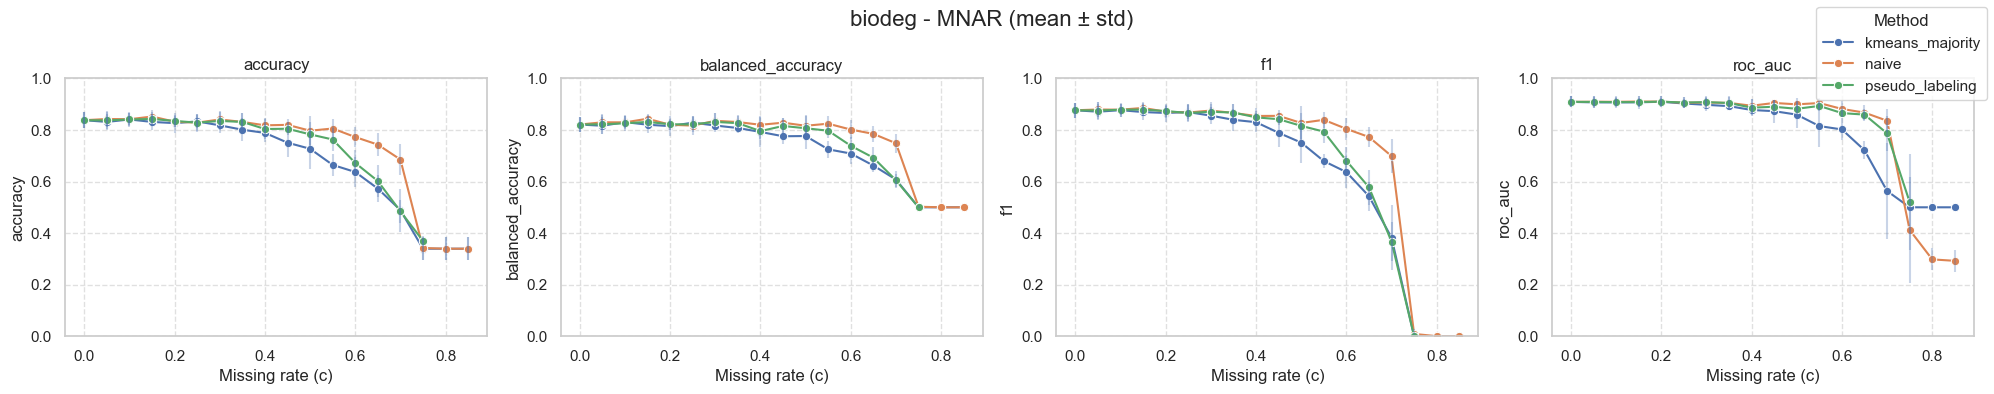

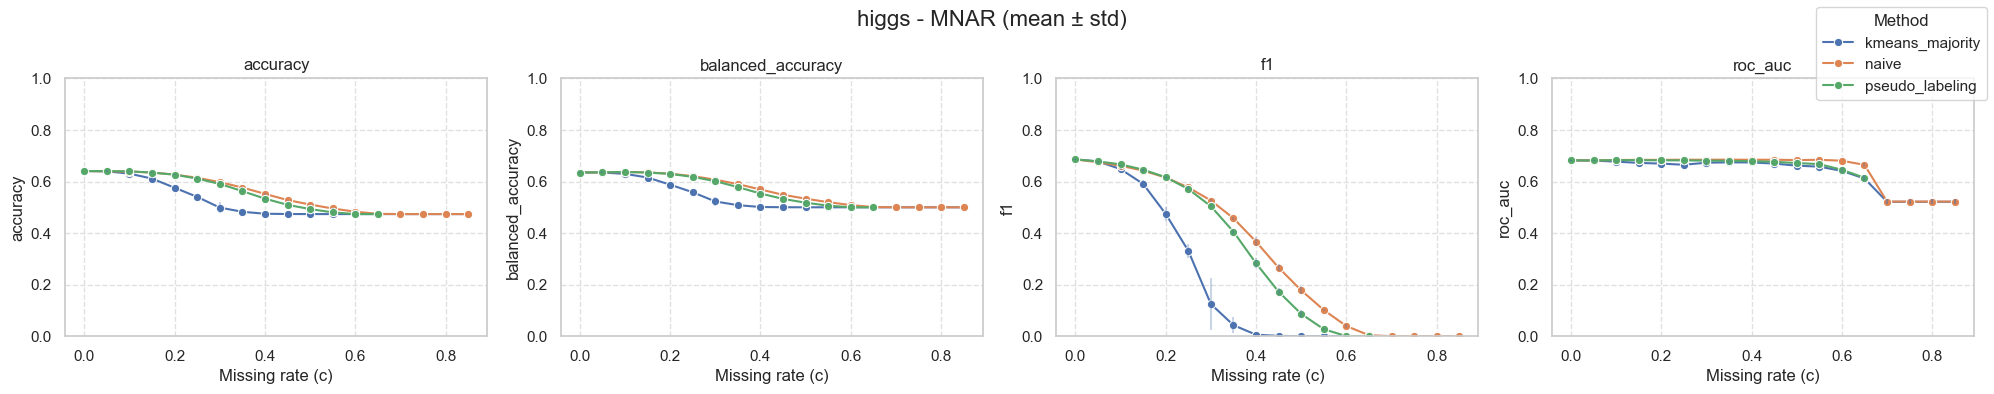

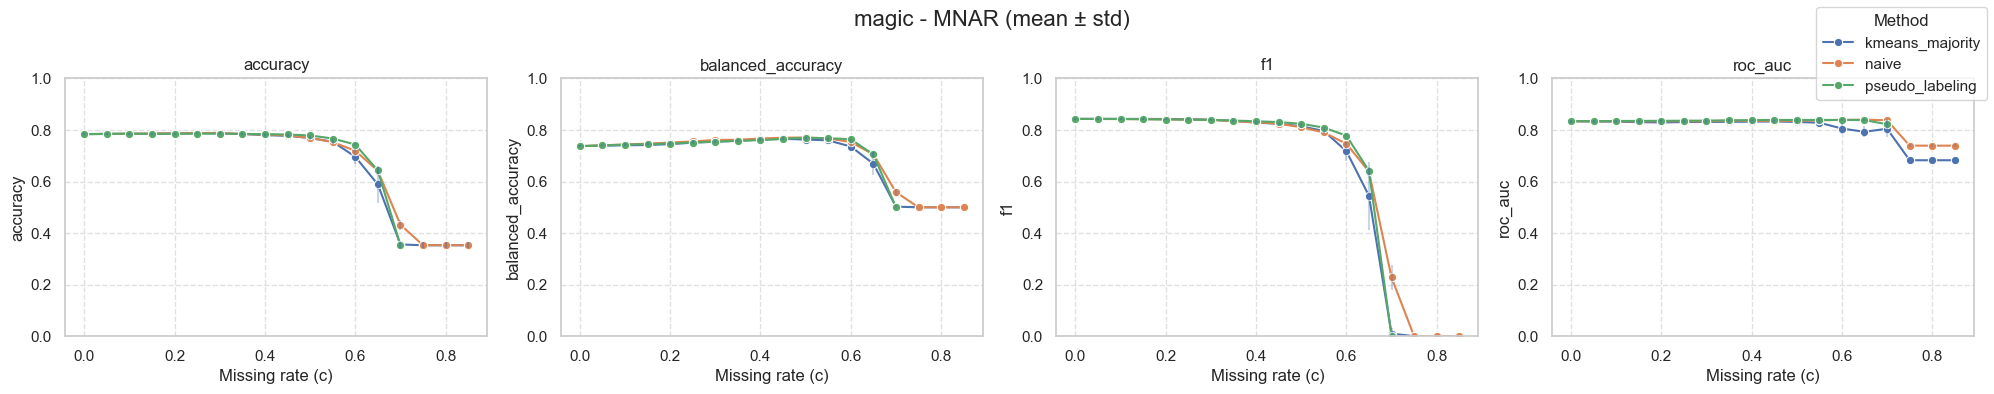

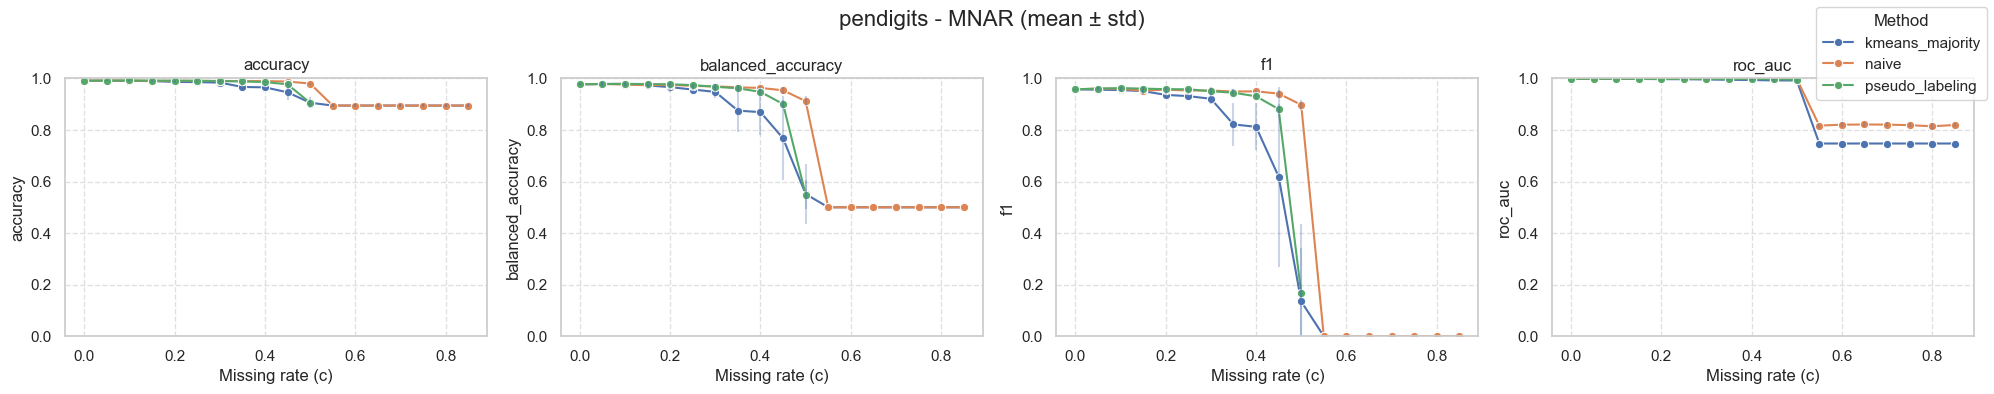

In [ ]:
sns.set_style("whitegrid")

df_plot = table_exp2.copy()

df_plot = df_plot[df_plot["method"] != "oracle"]

for dataset in df_plot["dataset"].unique():
    df_d = df_plot[df_plot["dataset"] == dataset]

    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True)

    for i, metric in enumerate(metrics):

        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"

        sns.lineplot(
            data=df_d,
            x="missing_rate",
            y=mean_col,
            hue="method",
            marker="o",
            ax=axes[i]
        )

        for method in df_d["method"].unique():
            df_m = df_d[df_d["method"] == method]
            axes[i].errorbar(
                df_m["missing_rate"],
                df_m[mean_col],
                yerr=df_m[std_col],
                fmt="none",
                alpha=0.3
            )

        axes[i].set_title(metric)
        axes[i].set_xlabel("Missing rate (c)")
        axes[i].set_ylabel(metric)
        axes[i].grid(True, linestyle="--", alpha=0.6)
        axes[i].set_ylim(0, 1)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Method", loc="upper right")

    for ax in axes:
        ax.legend().remove()

    fig.suptitle(f"{dataset} - MNAR (mean ± std)", fontsize=16)
    plt.tight_layout()
    plt.show()